<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-exercicios-probabilidade-amostragem/blob/main/MALU_Desafio_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESAFIO

Considerando a base de dados de populacao_brasileira.csv responda as
questões abaixo (os dados são fictícios).
Você é uma pesquisadora desenvolvendo uma análise sobre as
características da força de trabalho nos estados brasileiros. Responda as
perguntas abaixo:
1. Considere pessoas fluentes em inglês, qual a probabilidade
complementar? Ou seja, qual a probabilidade de escolhermos uma
pessoa aleatória e ela não ser fluente em inglês. Considere fluente
quem tem o nível avançado.
2. Se uma pessoa escolhida aleatoriamente for de Alagoas ou do Pará,
qual é a probabilidade de ela ter uma renda superior a 5 mil reais?
3. Descubra a probabilidade de uma pessoa ter ensino superior completo
no estado do Amazonas. Qual a probabilidade da quinta pessoa que
você conversar, que é amazonense, ter ensino superior completo?
4. Considerando a renda das pessoas do nosso conjunto, podemos dizer
que a renda de uma pessoa brasileira está na sua maioria em que faixa
(faça faixa de 1.500 reais)? Qual é a sua função densidade de
probabilidade?
5. Calcule a média e a variância da renda da amostra. Depois faça a
distribuição normal, inclua o gráfico.
6. Primeiro considere a probabilidade encontrada no nosso conjunto de
pessoas com escolaridade de pós-graduação. Considerando a amostra
de população brasileira com 1 milhão de habitantes, qual a
probabilidade de encontrarmos 243 mil pessoas com pós-graduação?
7. Somando as densidades nós temos a função de densidade acumulada.
Considerando a coluna ‘Escolaridade’ faça a função de densidade
acumulada discreta para cada nível de escolaridade.
8. Qual a margem de erro amostral da proporção populacional
considerando a proporção de pessoas com nível de inglês
intermediário?
9. Calcula a renda da população. Qual a probabilidade de encontrar 60
pessoas com uma renda mil reais superior à média?
10. Qual a probabilidade de escolhermos alguém do Sudeste que seja
homem, com ensino fundamental e com renda maior que 2 mil reais por
mês?

In [42]:
# bibliotecas de base
import pandas as pd
import numpy as np

# bibliotecas para visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# bibliotecas auxiliares
from collections import Counter

# biblioteca para estatística
import scipy.stats as stats

# imports de apoio
from scipy.stats import norm

In [20]:
url = 'https://raw.githubusercontent.com/i-malur/bootcamp-dados-exercicios-probabilidade-amostragem/refs/heads/main/populacao_brasileira.csv'
df = pd.read_csv(url)

# Análise exploratória

In [21]:
df.head()

,Unnamed: 0,estado,idade,escolaridade,nível de proficiência em inglês,renda,sexo
0,0,MA,56,Fundamental,Intermediário,4006.29,F
1,1,BA,46,Superior,Básico,2423.11,M
2,2,AM,32,Fundamental,Intermediário,3835.69,M
3,3,CE,60,Superior,Básico,1870.29,M
4,4,SE,25,Fundamental,Avançado,3529.80,M


In [22]:
df = df.drop('Unnamed: 0', axis=1)

In [23]:
df = df.rename(columns={
    'nível de proficiência em inglês': 'proficiencia em ingles'
})

In [24]:
df.head(2)

,estado,idade,escolaridade,proficiencia em ingles,renda,sexo
0,MA,56,Fundamental,Intermediário,4006.29,F
1,BA,46,Superior,Básico,2423.11,M


In [25]:
print('informações básicas do dataframe:')

print('-'*90)
print('\n\ntipos de dados de cada coluna:')
df.info()

print('-'*90)
print('\n\nverificando valores vazios nas colunas')
print(df.isnull().sum())

print('-'*90)
print('\n\nlinhas e colunas do dataframe')
print(df.shape)

print('-'*90)
print('\n\nestatísticas do dataframe')
df.describe()

informações básicas do dataframe:
------------------------------------------------------------------------------------------


tipos de dados de cada coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   estado                  1000 non-null   object 
 1   idade                   1000 non-null   int64  
 2   escolaridade            1000 non-null   object 
 3   proficiencia em ingles  1000 non-null   object 
 4   renda                   1000 non-null   float64
 5   sexo                    1000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 47.0+ KB
------------------------------------------------------------------------------------------


verificando valores vazios nas colunas
estado                    0
idade                     0
escolaridade              0
proficiencia em ingles    0
renda 

,idade,renda
count,1000.000000,1000.000000
mean,40.986000,3082.537180
std,13.497852,996.572239
min,18.000000,103.740000
25%,29.000000,2425.815000
50%,42.000000,3076.415000
75%,52.000000,3714.487500
max,64.000000,5632.380000


# Questão 01:

Considere pessoas fluentes em inglês, qual a probabilidade
complementar? Ou seja, qual a probabilidade de escolhermos uma
pessoa aleatória e ela não ser fluente em inglês. Considere fluente
quem tem o nível avançado

Probabilidade complementar de uma pessoa NÃO ser fluente, fórmula:

P(não fluente) = 1 − P(avançado)

In [30]:
p_fluente = (df['proficiencia em ingles'] == 'Avançado').mean()

p_nao_fluente = 1 - p_fluente

print(f'A probabilidade de escolhermos uma pessoa que não é fluente em inglês é: {p_nao_fluente} ou {p_nao_fluente:.2%}')

A probabilidade de escolhermos uma pessoa que não é fluente em inglês é: 0.656 ou 65.60%


# Questão 02:

Se uma pessoa escolhida aleatoriamente for de Alagoas ou do Pará,
qual é a probabilidade de ela ter uma renda superior a 5 mil reais?

In [36]:
estados_al_pa = df[df['estado'].isin(['PA', 'AL'])]
probabilidade = (estados_al_pa['renda'] > 5000).mean()

print(f'A probabilidade de escolhermos uma pessoa de Alagoas ou Pará que tenha renda maior que 5000 é: {probabilidade.round(4)} ou {probabilidade:.2%}')

A probabilidade de escolhermos uma pessoa de Alagoas ou Pará que tenha renda maior que 5000 é: 0.0506 ou 5.06%


# Questão 03
Descubra a probabilidade de uma pessoa ter ensino superior completo
no estado do Amazonas. Qual a probabilidade da quinta pessoa que
você conversar, que é amazonense, ter ensino superior completo?

In [38]:
# probabilidade de uma pessoa do estado do Amazonas ter o superior completo
amazonas = df[df['estado'] == 'AM']
superior = (amazonas['escolaridade'] == 'Superior').mean()
print(f'A probabilidade de escolhermos uma pessoa do estado do Amazonas com o superior completo é: {superior.round(4)} ou {superior:.2%}')

A probabilidade de escolhermos uma pessoa do estado do Amazonas com o superior completo é: 0.2368 ou 23.68%


Probabilidade da quinta pessoa amazonense ter o ensino superior completo, ou seja:

* as quatro primeiras não devem ter o superior e a quinta tenha.

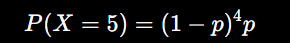

In [40]:
probabilidade_quinta_pessoa = (1-superior)**4 * superior
print(f'A probabilidade da quinta pessoa amazonense ter o superior completo é: {probabilidade_quinta_pessoa.round(4)} ou {probabilidade_quinta_pessoa:.2%}')

A probabilidade da quinta pessoa amazonense ter o superior completo é: 0.0803 ou 8.03%


# Questão 04
Considerando a renda das pessoas do nosso conjunto, podemos dizer
que a renda de uma pessoa brasileira está na sua maioria em que faixa
(faça faixa de 1.500 reais)? Qual é a sua função densidade de
probabilidade?


Criando as faixas:

* 0-1500
* 1500-3000
* 3000-4500
* 4500-6000

In [57]:
bins = np.arange(0, df['renda'].max() + 1500, 1500)
faixas = pd.cut(df['renda'], bins)

frequencias = faixas.value_counts().sort_index()

faixa_maior = frequencias.idxmax()
contagem = faixas.value_counts().max()

print(frequencias)
print(f'\n\nA faixa de renda com maior frequência é: {faixa_maior}, com {contagem} pessoas.')

renda
(0.0, 1500.0]        55
(1500.0, 3000.0]    414
(3000.0, 4500.0]    442
(4500.0, 6000.0]     89
Name: count, dtype: int64


A faixa de renda com maior frequência é: (3000.0, 4500.0], com 442 pessoas


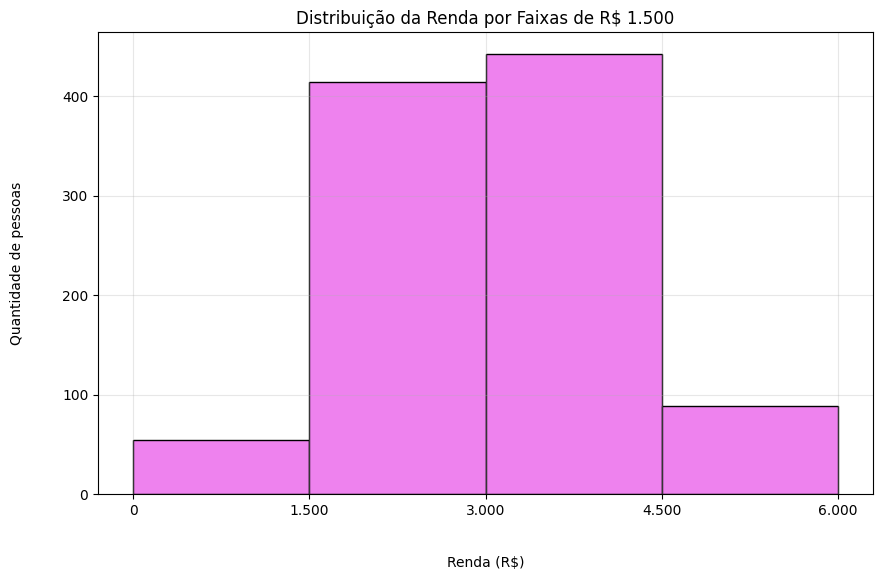

In [89]:
plt.figure(figsize=(10,6))

plt.hist(
  df['renda'],
  bins=np.arange(0, df['renda'].max()+1500, 1500),
  edgecolor='black',
  color='#EE82EE'
)

plt.xticks(
    [0, 1500, 3000, 4500, 6000],
    ['0', '1.500', '3.000', '4.500', '6.000']
)

plt.title('Distribuição da Renda por Faixas de R$ 1.500')
plt.xlabel('\n\nRenda (R$)')
plt.ylabel('Quantidade de pessoas\n\n')

plt.grid(alpha=0.3)

plt.show()

A distribuição da renda foi agrupada em faixas de RS 1.500. Observa-se que a maior concentração de pessoas está na faixa entre RS 3.000 e RS 4.500, indicando que essa é a faixa de renda predominante na amostra.

# Questão 05
Calcule a média e a variância da renda da amostra. Depois faça a
distribuição normal, inclua o gráfico.


In [67]:
media_renda = df['renda'].mean()
variancia_renda = df['renda'].var()
desvio_renda = df['renda'].std()

print(f'Média de renda da população (na amostra): {media_renda.round(2)} e a variância da renda: {variancia_renda}. O desvio padrão é {desvio_renda}')

Média de renda da população (na amostra): 3082.54 e a variância da renda: 993156.228167617. O desvio padrão é 996.5722393121418


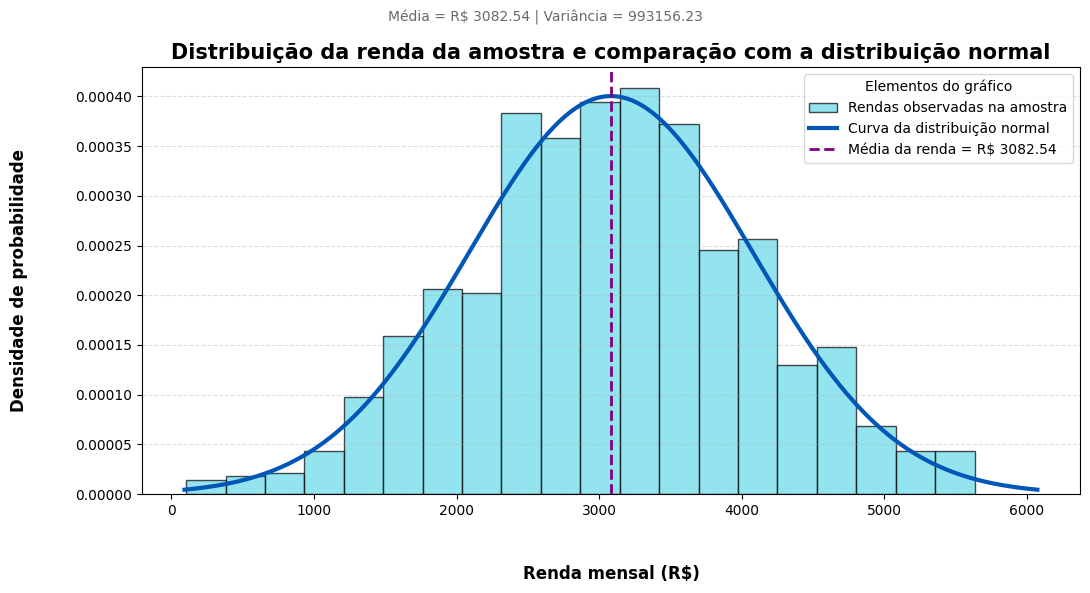

In [100]:

plt.figure(figsize=(11,6))

# Histograma da amostra
plt.hist(
    df['renda'],
    bins=20,
    density=True,
    color='#66D9E8',
    edgecolor='black',
    alpha=0.7,
    label='Rendas observadas na amostra'
)

# Curva normal
x = np.linspace(media_renda - 3 * desvio_renda, media_renda + 3 * desvio_renda, 1000)

plt.plot(
    x,
    norm.pdf(x, media_renda, desvio_renda),
    color='#0057B8',
    linewidth=3,
    label='Curva da distribuição normal'
)

# Média
plt.axvline(
    media_renda,
    color='#800080',
    linestyle='--',
    linewidth=2,
    label=f'Média da renda = R$ {media_renda:.2f}'
)

plt.title(
    'Distribuição da renda da amostra e comparação com a distribuição normal',
    fontsize=15,
    fontweight='bold'
)

plt.suptitle(
    f'Média = R$ {media_renda:.2f} | Variância = {variancia_renda:.2f}',
    fontsize=10,
    color='dimgray'
)

plt.xlabel('\n\nRenda mensal (R$)', fontsize=12, fontweight='bold')
plt.ylabel('Densidade de probabilidade\n\n', fontsize=12, fontweight='bold')

plt.legend(title='Elementos do gráfico')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

A distribuição da renda apresenta maior concentração entre aproximadamente RS 2.500 e RS 3.500, com média de RS 3.082,54. O formato do histograma é bastante semelhante ao de uma distribuição normal, apresentando um comportamento fortemente simétrico em torno da média, com as frequências diminuindo gradualmente à medida que se afastam do centro.

# Questão 06

Primeiro considere a probabilidade encontrada no nosso conjunto de
pessoas com escolaridade de pós-graduação. Considerando a amostra
de população brasileira com 1 milhão de habitantes, qual a
probabilidade de encontrarmos 243 mil pessoas com pós-graduação?

In [98]:
p = (df['escolaridade'] == 'Pós-graduação').mean()

In [101]:
n = 1_000_000
k = 243_000

# média e o desvio padrão teóricos da binomial
media_ficticia = n * p
desvio_ficticio = np.sqrt(n * p * (1 - p))

# aproximação pela Normal com correção de continuidade
# probabilidade acumulada até (k + 0.5) e subtraímos a até (k - 0.5)
prob_aproximada = norm.cdf(k + 0.5, loc=media_ficticia, scale=desvio_ficticio) - \
                  norm.cdf(k - 0.5, loc=media_ficticia, scale=desvio_ficticio)

print(f"A probabilidade exata aproximada pela distribuição normal é: {prob_aproximada}")

A probabilidade exata aproximada pela Normal é: 1.160242173948329e-118


A probabilidade de encontrarmos exatamente 243.000 pessoas com pós-graduação em uma amostra de 1.000.000 de habitantes é de aproximadamente $1,16 \times 10^{-118}$ (ou seja, praticamente 0%).  

Justificativa Teórica: Devido ao grande tamanho da amostra ($n = 1.000.000$), foi utilizada a aproximação da Distribuição Binomial pela Distribuição Normal com correção de continuidade.Em amostras de grande escala, o desvio padrão amostral torna-se muito pequeno, concentrando quase toda a probabilidade estritamente ao redor da média real da população. Como o valor de 243.000 pessoas está afastado da média esperada pelo comportamento do nosso conjunto de dados, a chance de obter exatamente esse número de indivíduos por puro acaso é estatisticamente desprezível (equivalente a zero).

# Questão 07
Somando as densidades nós temos a função de densidade acumulada.
Considerando a coluna ‘Escolaridade’ faça a função de densidade
acumulada discreta para cada nível de escolaridade.


In [104]:
ordem_escolaridade = ['Fundamental', 'Médio', 'Superior', 'Pós-graduação']

# contar a frequência absoluta (quantidade de pessoas)
tabela_fda = df['escolaridade'].value_counts().reindex(ordem_escolaridade).to_frame(name='Frequência absoluta')

# calcular a Densidade (Frequência Relativa / Probabilidade)
tabela_fda['Densidade (PMF)'] = df['escolaridade'].value_counts(normalize=True).reindex(ordem_escolaridade)

# calcular a Densidade acumulada (soma cumulativa)
tabela_fda['Densidade acumulada (FDA)'] = tabela_fda['Densidade (PMF)'].cumsum()

print(tabela_fda)

               Frequência absoluta  Densidade (PMF)  Densidade acumulada (FDA)
escolaridade                                                                  
Fundamental                    266            0.266                      0.266
Médio                          238            0.238                      0.504
Superior                       243            0.243                      0.747
Pós-graduação                  253            0.253                      1.000


# Questão 08

Qual a margem de erro amostral da proporção populacional considerando a proporção de pessoas com nível de inglês
intermediário?

Colocamos 95% de confiança, onde Z = 1,96

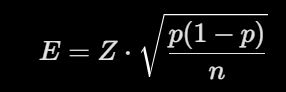

In [105]:
df.head(1)

,estado,idade,escolaridade,proficiencia em ingles,renda,sexo
0,MA,56,Fundamental,Intermediário,4006.29,F


In [108]:
p_inter = (df['proficiencia em ingles'] == 'Intermediário').mean()
n = len(df)
z = 1.96 # para 95% de confiança

margem_erro = z * np.sqrt((p_inter * (1 - p_inter)) / n)

print(f'A margem de erro é de {margem_erro.round(4)}, para 95% de confiança.')

A margem de erro é de 0.0291, para 95% de confiança.


# Questão 09

Calcula a renda da população. Qual a probabilidade de encontrar 60 pessoas com uma renda mil reais superior à média?

In [112]:
# renda média e desvio padrão amostral
mu = df['renda'].mean()
sigma = df['renda'].std()
n_grupo = 60

# erro padrão da média
erro_padrao = sigma / np.sqrt(n_grupo)

# média do grupo > mu + 1000
# sobrevivência (sf) da normal: 1 - cdf
p_grupo = norm.sf(mu + 1000, loc=mu, scale=erro_padrao)

print(f'Probabilidade de encontrar 60 pessoas com renda mil reais superior a média {p_grupo}')

Probabilidade de encontrar 60 pessoas com renda mil reais superior a média 3.844279417904096e-15


 Erro Padrão da Média ($\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$).   

 A função de sobrevivência (norm.sf), é a forma mais precisa no Python para calcular a cauda direita da distribuição normal ($P(X > \mu + 1000)$).

# Questão 10

Qual a probabilidade de escolhermos alguém do Sudeste que seja homem, com ensino fundamental e com renda maior que 2 mil reais por mês?

In [116]:
nordeste = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
norte = ['AM', 'AP', 'AC', 'PA', 'RO', 'RR', 'TO']
sudeste = ['SP', 'RJ', 'ES', 'MG']
centro_oeste = ['DF', 'GO', 'MT', 'MS']
sul = ['RS', 'SC', 'PR']

regioes = ['Nordeste', 'Norte', 'Sudeste', 'Centro-Oeste', 'Sul']

condicoes = [
    df['estado'].isin(nordeste),
    df['estado'].isin(norte),
    df['estado'].isin(sudeste),
    df['estado'].isin(centro_oeste),
    df['estado'].isin(sul)
]

df['regiao'] = np.select(condicoes, regioes, default='Não Identificado')

df.head(7)

,estado,idade,escolaridade,proficiencia em ingles,renda,sexo,regiao
0,MA,56,Fundamental,Intermediário,4006.29,F,Nordeste
1,BA,46,Superior,Básico,2423.11,M,Nordeste
2,AM,32,Fundamental,Intermediário,3835.69,M,Norte
3,CE,60,Superior,Básico,1870.29,M,Nordeste
4,SE,25,Fundamental,Avançado,3529.80,M,Nordeste
5,AM,38,Fundamental,Avançado,4441.57,F,Norte
6,DF,56,Médio,Intermediário,528.36,F,Centro-Oeste


In [120]:
condicao = (df['regiao'] == 'Sudeste') & (df['sexo'] == 'M') & (df['escolaridade'] == 'Fundamental') & (df['renda'] > 2000)
p_total = condicao.mean()

print(f'Probabilidade de escolhermos um homem do sudeste com ensino fundamental e renda maior que 2000 reais por mês {p_total}.')

Probabilidade de escolhermos um homem do sudeste com ensino fundamental e renda maior que 2000 reais por mês 0.019.
